In [12]:
#Celda 1: Instalación y Carga de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Manejo de desbalanceo
from imblearn.over_sampling import SMOTE

# Configuración visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [13]:
#Celda 2: Carga y Limpieza de Datos (Ruta Local)
# Definimos el path local que indicaste
path_archivo = "data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

try:
    # Carga del dataset desde el almacenamiento local de Colab
    df = pd.read_csv(path_archivo)
    print("Archivo cargado exitosamente desde el almacenamiento local.")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {path_archivo}. Por favor, asegúrate de haberlo subido a la carpeta sample_data.")

# 1. Eliminación de variables con varianza cero (Data Quality Issues)
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# Usamos errors='ignore' por si alguna columna ya fue borrada en una ejecución previa
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 2. Reemplazo directo y forzado de tipo en columnas Attrition & Overtime (str a int)
mapping = {'Yes': 1, 'No': 0}

df['Attrition'] = df['Attrition'].map(mapping).fillna(0).astype(int)
df['OverTime'] = df['OverTime'].map(mapping).fillna(0).astype(int)

print(f"Dataset procesado: {df.shape[0]} filas y {df.shape[1]} columnas.")

extremos = pd.concat([df.head(3), df.tail(3)])
display(extremos)

Archivo cargado exitosamente desde el almacenamiento local.
Dataset procesado: 1470 filas y 31 columnas.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8
1469,34,0,Travel_Rarely,628,Research & Development,8,3,Medical,2,Male,...,3,1,0,6,3,4,4,3,1,2


Segmento Junior/Semi-Senior (JobLevel 1-2): 1077 filas
Segmento Senior/Gerencial (JobLevel 3-5): 393 filas


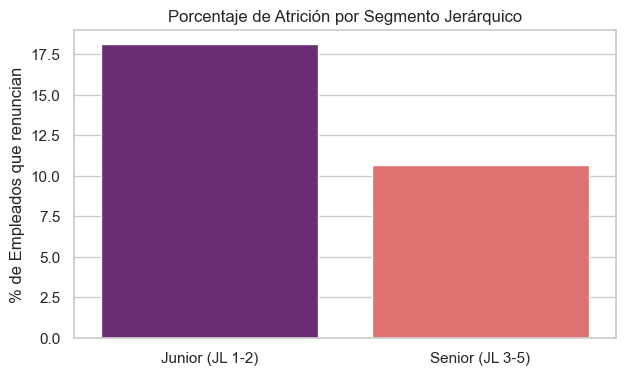

Tasa Atrición Junior: 18.11%
Tasa Atrición Senior: 10.69%

Ingreso promedio Junior: 4133.25069637883
Ingreso promedio Senior: 12996.941475826972


In [14]:
#Celda 3: Análisis de Segmentación
# Segmentación sugerida por el tutor
df_junior = df[df['JobLevel'] <= 2].copy()
df_senior = df[df['JobLevel'] >= 3].copy()

print(f"Segmento Junior/Semi-Senior (JobLevel 1-2): {len(df_junior)} filas")
print(f"Segmento Senior/Gerencial (JobLevel 3-5): {len(df_senior)} filas")

# Visualización de Atrición por Segmento
plt.figure(figsize=(7, 4))
sns.barplot(x=['Junior (JL 1-2)', 'Senior (JL 3-5)'],
            y=[df_junior['Attrition'].mean() * 100, df_senior['Attrition'].mean() * 100],
            palette='magma')
plt.title('Porcentaje de Atrición por Segmento Jerárquico')
plt.ylabel('% de Empleados que renuncian')
plt.show()

# Tasa de atrición por segmento
print(f"Tasa Atrición Junior: {df_junior['Attrition'].mean():.2%}")
print(f"Tasa Atrición Senior: {df_senior['Attrition'].mean():.2%}")

# Comparar variables clave por segmento
print("\nIngreso promedio Junior:", df_junior['MonthlyIncome'].mean())
print("Ingreso promedio Senior:", df_senior['MonthlyIncome'].mean())



In [15]:
#Celda 4: Preprocesamiento Global y Baseline
# 1. Separar X e y
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 2. Convertir TODAS las variables categóricas a números (Dummies)
# Esto evita errores de tipos de datos en la Regresión Logística
X = pd.get_dummies(X, drop_first=True)

# 3. Split Estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Escalamiento Robusto (Manejo de Outliers según tu pre-entrega)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Baseline: Regresión Logística
baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred_base = baseline.predict(X_test_scaled)

print("--- REPORTE BASELINE (REGRESIÓN LOGÍSTICA) ---")
print(classification_report(y_test, y_pred_base))

--- REPORTE BASELINE (REGRESIÓN LOGÍSTICA) ---
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [16]:
#Celda 5: Modelo Final (Random Forest + SMOTE)
# 1. Balanceo con SMOTE sobre el set de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 2. Entrenamiento de Random Forest
rf_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# 3. Predicciones
y_pred_rf = rf_model.predict(X_test_scaled)
y_probs_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("--- RESULTADOS MODELO FINAL (RANDOM FOREST) ---")
print(f"Recall: {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_probs_rf):.2f}")




--- RESULTADOS MODELO FINAL (RANDOM FOREST) ---
Recall: 0.26
F1-Score: 0.34
AUC-ROC: 0.81


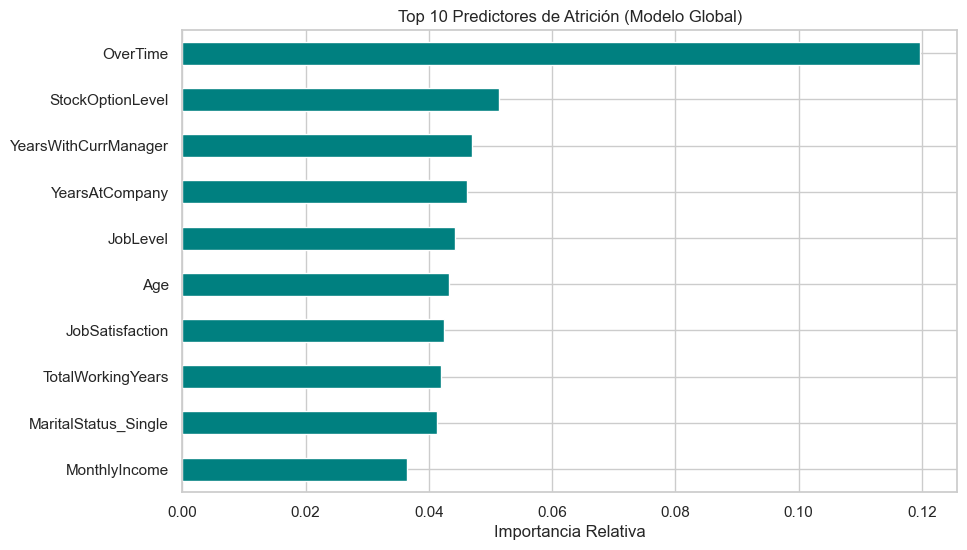

OverTime                0.119715
StockOptionLevel        0.051364
YearsWithCurrManager    0.046976
YearsAtCompany          0.046210
JobLevel                0.044179
Age                     0.043209
JobSatisfaction         0.042397
TotalWorkingYears       0.041990
MaritalStatus_Single    0.041406
MonthlyIncome           0.036403
dtype: float64


In [17]:
#Celda 6: Importancia de Variables (Feature Importance)
# Extraer importancia de las variables
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
top_variables = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_variables.plot(kind='barh', color='teal')
plt.title('Top 10 Predictores de Atrición (Modelo Global)')
plt.xlabel('Importancia Relativa')
plt.gca().invert_yaxis()
plt.show()

# Ver valores exactos de importancia
importancias_exactas = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias_exactas.head(10))


In [18]:
#Celda 7: Evaluación de Impacto (KPI de Negocio)
# n = Empleados en riesgo detectados por el modelo
n_riesgo = (y_pred_rf == 1).sum()

# MonthlyIncome promedio de los detectados (usando el índice del test set)
indices_test = y_test.index
ingreso_promedio_riesgo = df.loc[indices_test[y_pred_rf == 1], 'MonthlyIncome'].mean()

# Tu fórmula: Σ (MonthlyIncome * 6)
# Asumiendo una efectividad del 50% en las acciones de RRHH
costo_reposicion_total = n_riesgo * (ingreso_promedio_riesgo * 6)
ahorro_potencial = costo_reposicion_total * 0.5

print(f"Resultados de Negocio:")
print(f"- Empleados detectados en riesgo: {n_riesgo}")
print(f"- Costo de reposición total estimado: ${costo_reposicion_total:,.2f} USD")
print(f"- Ahorro potencial (50% efectividad retención): ${ahorro_potencial:,.2f} USD")


Resultados de Negocio:
- Empleados detectados en riesgo: 24
- Costo de reposición total estimado: $431,094.00 USD
- Ahorro potencial (50% efectividad retención): $215,547.00 USD
